In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
house_price = pd.read_csv("HousePricePrediction.csv")

In [3]:
house_price

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

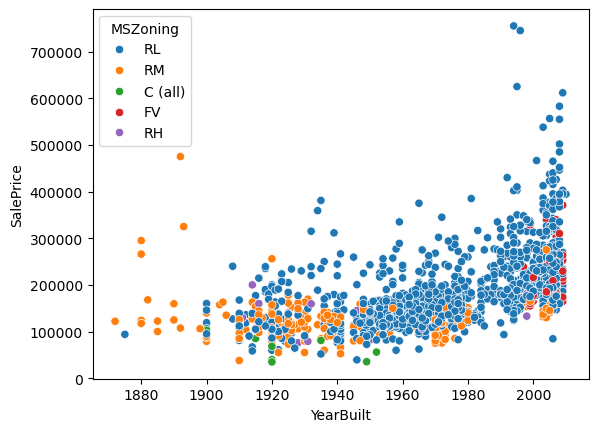

In [4]:
sns.scatterplot(
    data = house_price,
    x = "YearBuilt",
    y = "SalePrice",
    hue = "MSZoning",
)

<Axes: xlabel='YearRemodAdd', ylabel='SalePrice'>

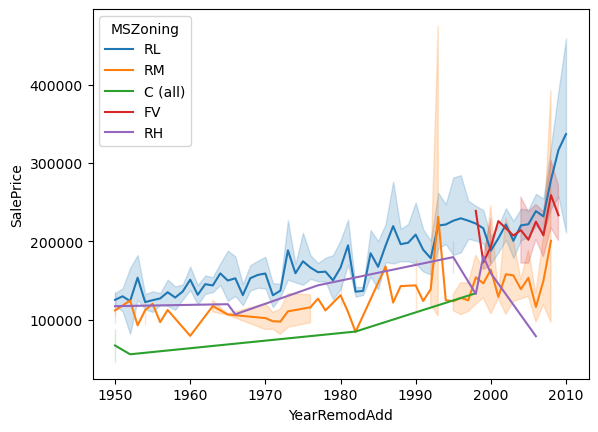

In [5]:
sns.lineplot(
    data = house_price,
    x = "YearRemodAdd",
    y = "SalePrice",
    hue = "MSZoning",
)

In [6]:
unique = house_price["MSZoning"].unique()
lot_config_unique = house_price["LotConfig"].unique()
BldgType_unique = house_price["BldgType"].unique()
Exterior1st_unique = house_price["Exterior1st"].unique()

In [7]:
column_encoding = ["MSZoning","LotConfig","BldgType"]
encoded1 = pd.get_dummies(house_price,columns = column_encoding)
encoded1

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice,...,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
0,0,60,8450,5,2003,2003,VinylSd,0.0,856.0,208500.0,...,False,False,False,False,True,True,False,False,False,False
1,1,20,9600,8,1976,1976,MetalSd,0.0,1262.0,181500.0,...,False,False,True,False,False,True,False,False,False,False
2,2,60,11250,5,2001,2002,VinylSd,0.0,920.0,223500.0,...,False,False,False,False,True,True,False,False,False,False
3,3,70,9550,5,1915,1970,Wd Sdng,0.0,756.0,140000.0,...,True,False,False,False,False,True,False,False,False,False
4,4,60,14260,5,2000,2000,VinylSd,0.0,1145.0,250000.0,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,1936,7,1970,1970,CemntBd,0.0,546.0,NaN,...,False,False,False,False,True,False,False,False,True,False
2915,2915,160,1894,5,1970,1970,CemntBd,0.0,546.0,NaN,...,False,False,False,False,True,False,False,False,False,True
2916,2916,20,20000,7,1960,1996,VinylSd,0.0,1224.0,NaN,...,False,False,False,False,True,True,False,False,False,False
2917,2917,85,10441,5,1992,1992,HdBoard,0.0,912.0,NaN,...,False,False,False,False,True,True,False,False,False,False


In [8]:
bool_col = ['MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL',
       'MSZoning_RM', 'LotConfig_Corner', 'LotConfig_CulDSac', 'LotConfig_FR2',
       'LotConfig_FR3', 'LotConfig_Inside', 'BldgType_1Fam', 'BldgType_2fmCon',
       'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE']
encoded1[bool_col] = encoded1[bool_col].astype(int)

In [11]:
encoded = encoded1.replace({"True": 1 , "False" : 0})

In [12]:
encoded

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice,...,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE
0,0,60,8450,5,2003,2003,VinylSd,0.0,856.0,208500.0,...,0,0,0,0,1,1,0,0,0,0
1,1,20,9600,8,1976,1976,MetalSd,0.0,1262.0,181500.0,...,0,0,1,0,0,1,0,0,0,0
2,2,60,11250,5,2001,2002,VinylSd,0.0,920.0,223500.0,...,0,0,0,0,1,1,0,0,0,0
3,3,70,9550,5,1915,1970,Wd Sdng,0.0,756.0,140000.0,...,1,0,0,0,0,1,0,0,0,0
4,4,60,14260,5,2000,2000,VinylSd,0.0,1145.0,250000.0,...,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,1936,7,1970,1970,CemntBd,0.0,546.0,NaN,...,0,0,0,0,1,0,0,0,1,0
2915,2915,160,1894,5,1970,1970,CemntBd,0.0,546.0,NaN,...,0,0,0,0,1,0,0,0,0,1
2916,2916,20,20000,7,1960,1996,VinylSd,0.0,1224.0,NaN,...,0,0,0,0,1,1,0,0,0,0
2917,2917,85,10441,5,1992,1992,HdBoard,0.0,912.0,NaN,...,0,0,0,0,1,1,0,0,0,0


In [13]:
encoded.isnull().sum()

Id                      0
MSSubClass              0
LotArea                 0
OverallCond             0
YearBuilt               0
YearRemodAdd            0
Exterior1st             1
BsmtFinSF2              1
TotalBsmtSF             1
SalePrice            1459
MSZoning_C (all)        0
MSZoning_FV             0
MSZoning_RH             0
MSZoning_RL             0
MSZoning_RM             0
LotConfig_Corner        0
LotConfig_CulDSac       0
LotConfig_FR2           0
LotConfig_FR3           0
LotConfig_Inside        0
BldgType_1Fam           0
BldgType_2fmCon         0
BldgType_Duplex         0
BldgType_Twnhs          0
BldgType_TwnhsE         0
dtype: int64

In [14]:
encoded.columns

Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice',
       'MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL',
       'MSZoning_RM', 'LotConfig_Corner', 'LotConfig_CulDSac', 'LotConfig_FR2',
       'LotConfig_FR3', 'LotConfig_Inside', 'BldgType_1Fam', 'BldgType_2fmCon',
       'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE'],
      dtype='object')

In [16]:
encoded["TotalBsmtSF"] = encoded1["TotalBsmtSF"].fillna(
    encoded["TotalBsmtSF"].mean()
)
encoded['SalePrice'] = encoded1['SalePrice'].fillna(
    encoded['SalePrice'].mean()
)
encoded["BsmtFinSF2"] = encoded1["BsmtFinSF2"].fillna(
    encoded["BsmtFinSF2"].mean()
)

In [17]:
encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id                 2919 non-null   int64  
 1   MSSubClass         2919 non-null   int64  
 2   LotArea            2919 non-null   int64  
 3   OverallCond        2919 non-null   int64  
 4   YearBuilt          2919 non-null   int64  
 5   YearRemodAdd       2919 non-null   int64  
 6   Exterior1st        2918 non-null   object 
 7   BsmtFinSF2         2919 non-null   float64
 8   TotalBsmtSF        2919 non-null   float64
 9   SalePrice          2919 non-null   float64
 10  MSZoning_C (all)   2919 non-null   int32  
 11  MSZoning_FV        2919 non-null   int32  
 12  MSZoning_RH        2919 non-null   int32  
 13  MSZoning_RL        2919 non-null   int32  
 14  MSZoning_RM        2919 non-null   int32  
 15  LotConfig_Corner   2919 non-null   int32  
 16  LotConfig_CulDSac  2919 

In [18]:
x = encoded.drop(columns = ['Id','Exterior1st','SalePrice'])
y = encoded["SalePrice"]

In [22]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.2 , random_state = 42)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(xtrain,ytrain)

y_pred = model.predict(xtest)

In [23]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2_score = r2_score(ytest,y_pred)
print("r2_score",r2_score)

r2_score 0.35085715817969854


In [24]:
mean_absolute_error = mean_absolute_error(y_pred,ytest)
print("MAE",mean_absolute_error)
mean_squared_error = mean_squared_error(y_pred,ytest)
print("MSE",mean_squared_error)

MAE 32209.166609642416
MSE 2315304351.7820206


In [25]:
house_price.to_excel("house_price_predict.xlsx",index = False)

In [26]:
print("testing data r2 score-",r2_score)

testing data r2 score- 0.35085715817969854


In [27]:
from sklearn.metrics import r2_score
ytrain_pred = model.predict(xtrain)
r2_train = r2_score(ytrain,ytrain_pred)
print("training data r2 score-",r2_train)

training data r2 score- 0.29356820924077465
